ILI SEIR

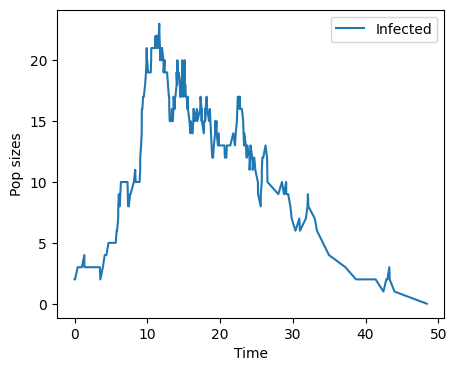

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ili_data = pd.read_csv("./data/ili_data.csv")
hhs1_data = ili_data.loc[ ili_data.region == "hhs1" ].reset_index()

n = 1000 
def seir(t,y, beta, gamma,n):
    s,e,i, r, c = y
    ds_dt = -beta*s*i/n
    de_dt = beta*s*i/n - sigma*e
    di_dt =  sigma*e - gamma*i
    dr_dt = gamma*i
    
    dc_dt = beta*s*i/n            #--incident cases (why?)
    return [ds_dt,de_dt, di_dt, dr_dt, dc_dt]

#--start and end times 
start,end = 0., 20

#--times that we want to return s(t), i(t), r(t)
tvals = np.arange(start,end+0.1,0.1)

#--inital conditions for s, i, r
initial_conditions = (999,0 ,1, 0., 0)

#--parameters for the model 
beta, sigma, gamma = 3./2, 1./3

#--function to return s,i,r over time
solution = solve_ivp( fun = sir
                     , t_span = (start,end)
                     , y0     = initial_conditions
                     , t_eval = tvals
                     , args   = (beta, gamma,n))
prevalent_infections = solution.y[1,:]
times                = solution.t 

plt.plot(times,prevalent_infections)
plt.xlabel("Time (days)")
plt.ylabel("Prevalent infections")
plt.show()




def direct_reaction(stop_time=200):
    import numpy as np

    #--start time and stop time
    t         = 0
    times     = [0]
  
    #--parameter values
    params     = {"beta":0.6, "sigma": 0.3, "gamma":0.2}
    pop        = {"S": [100], "E":[1], "I":[2], "R":[0], "N":[103] }
    
    while t <stop_time:        
        
        #--simulate times for all events
        S,E,I,R,N = pop.get("S"),pop.get("E"), pop.get("I"),pop.get("R"),pop.get("N")
        S     = S[-1]
        E     = E[-1]
        I     = I[-1]
        R     = R[-1]
        N     = N[-1]

        #--time of the next event 
        rate1 = np.clip( (params["beta"]*S*I/N )   ,0,np.inf) # S to E
        rate2 = np.clip( (params["sigma"] * E)     ,0,np.inf) # E to I 
        rate3 = np.clip( (params["gamma"] * I)     ,0,np.inf) # I to R
        
        T       =  rate1 + rate2 + rate3

        if T==0:
            break
        
        delta_T = np.random.exponential(1./T)

        #--choose which event occurs 
        if S==0 or I==0 or N==0:
            p_event1 = 0
        else:
            p_event1 = rate1/T #--time for event 1

        if E==0:
            p_event2 =0
        else:
            p_event2 = rate2/T     #--time for event 2

        if I == 0:
            p_event3 = 0
        else:
            p_event3 = rate3/T     #--time for event 3

        probs = np.array([p_event1,p_event2,p_event3])
        
        #--Find the event that occurs
        event_to_occur = np.random.choice( np.arange(3), p = probs/probs.sum() )     
        
        #--Implement the event by changing disease states
        if event_to_occur==0:
            S       = np.max( [S-1, 0]) 
            E       = E+1 
        elif event_to_occur==1:
            E       = np.max( [E-1, 0]) 
            I       = I+1
        elif event_to_occur==2:
            I       = np.max( [I-1, 0]) 
            R       = R+1
            
        #--Update numbers in each disease
        pop["S"].append(S)
        pop["E"].append(E)
        pop["I"].append(I)
        pop["R"].append(R)
        
        #--Update pop size 
        N = S+E+I+R
        pop["N"].append(N)

        t+=delta_T
        times.append(t)
    
    return times,pop

times,pop = direct_reaction(100)

fig,ax = plt.subplots(figsize=(5,4))

Is = pop["I"]
ax.plot(times,Is,label="Infected")    

ax.set_xlabel("Time")
ax.set_ylabel("Pop sizes")

ax.legend()

plt.show()

In [5]:
print(hhs1_data.head)

NameError: name 'hhs1_data' is not defined